In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/centralVN_dataWeather.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/aqi_centralVN_daily.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/aqi_southVN_daily.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataThoiTiet.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/southVN_dataAIR.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/centralVN.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/southVN_dataWeather.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/centralVN_dataAIR.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataAIR.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/southVN.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/aqi_northVN_daily.csv


In [20]:
df = pd.read_csv("/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN.csv")

In [21]:
df.head()

,district,city,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),...,pm2_5 (μg/m³),carbon_monoxide (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),dust (μg/m³),uv_index (),uv_index_clear_sky (),aqi_h
0,Ba Dinh,Ha Noi,2022-08-04 07:00:00,28.5,87,35.2,8,0,0,71,...,40.3,595.0,29.7,16.8,24.0,0.43,0.0,0.75,0.80,81
1,Ba Dinh,Ha Noi,2022-08-04 08:00:00,29.5,82,36.6,100,0,0,100,...,30.0,552.0,25.0,18.2,49.0,0.52,0.0,2.10,2.35,72
2,Ba Dinh,Ha Noi,2022-08-04 09:00:00,30.4,80,38.0,100,5,0,100,...,32.7,492.0,18.4,20.2,84.0,0.59,0.0,3.95,4.55,70
3,Ba Dinh,Ha Noi,2022-08-04 10:00:00,31.8,73,39.4,94,23,4,92,...,34.9,429.0,11.2,22.0,128.0,0.68,0.0,4.70,6.75,70
4,Ba Dinh,Ha Noi,2022-08-04 11:00:00,32.5,71,41.1,92,3,5,92,...,38.3,414.0,8.6,21.5,154.0,0.75,0.0,5.10,8.25,71


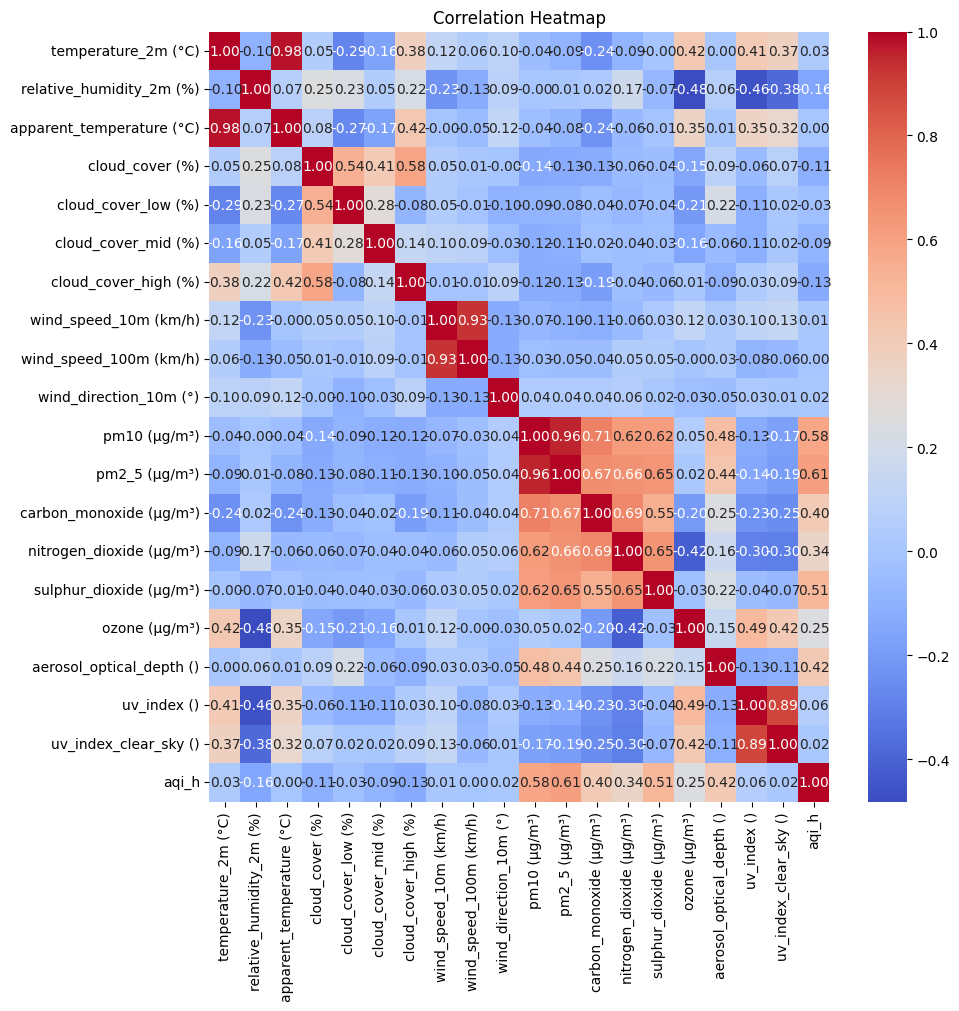

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# ví dụ dữ liệu
df1 = df[[
'temperature_2m (°C)',
'relative_humidity_2m (%)',
'apparent_temperature (°C)',
'cloud_cover (%)',
'cloud_cover_low (%)',
'cloud_cover_mid (%)',
'cloud_cover_high (%)',
'wind_speed_10m (km/h)',
'wind_speed_100m (km/h)',
'wind_direction_10m (°)',
'pm10 (μg/m³)',
'pm2_5 (μg/m³)',
'carbon_monoxide (μg/m³)',
'nitrogen_dioxide (μg/m³)',
'sulphur_dioxide (μg/m³)',
'ozone (μg/m³)',
'aerosol_optical_depth ()',
'uv_index ()',
'uv_index_clear_sky ()',
'aqi_h']]

# ma trận tương quan
corr = df1.corr()
# print(corr)

# vẽ heatmap
plt.figure(figsize=(10,10))

sns.heatmap(
    corr,
    annot=True,      # hiện số
    cmap='coolwarm', # màu
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

AQI có mối tương quan cao với:  
pm10  
pm25  
co2  
no2  
so2  
aod(độ trong khí quyển)  

In [30]:
df2 = df[(df['city'] == 'Ha Noi') & (df['district'] == 'Thanh Xuan')]
df2.head()

,district,city,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),...,pm2_5 (μg/m³),carbon_monoxide (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),dust (μg/m³),uv_index (),uv_index_clear_sky (),aqi_h
214655,Thanh Xuan,Ha Noi,2022-08-04 07:00:00,28.3,86,34.8,40,0,0,83,...,41.7,713.0,38.6,20.1,22.0,0.34,0.0,0.75,0.85,83
214656,Thanh Xuan,Ha Noi,2022-08-04 08:00:00,29.5,82,36.5,99,0,0,99,...,29.9,658.0,32.8,21.0,50.0,0.39,0.0,2.20,2.50,74
214657,Thanh Xuan,Ha Noi,2022-08-04 09:00:00,30.6,79,38.1,100,4,0,100,...,30.4,581.0,24.4,22.5,90.0,0.47,0.0,3.90,4.85,71
214658,Thanh Xuan,Ha Noi,2022-08-04 10:00:00,31.8,75,39.8,99,10,7,99,...,35.5,503.0,15.8,24.0,137.0,0.57,0.0,5.20,7.15,71
214659,Thanh Xuan,Ha Noi,2022-08-04 11:00:00,32.5,72,41.2,92,4,5,92,...,44.0,490.0,13.5,24.4,160.0,0.68,0.0,5.45,8.55,72


In [31]:
df2.shape

(30665, 32)

In [36]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


X = df2[['pm10 (μg/m³)', 'pm2_5 (μg/m³)', 'carbon_monoxide (μg/m³)','nitrogen_dioxide (μg/m³)','sulphur_dioxide (μg/m³)','aerosol_optical_depth ()']]
y = df2['aqi_h'] # Target variable


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

regressor = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
regressor.fit(X_train, y_train)

predictions = regressor.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 1176.1712445193916
R-squared: 0.36886473055815117


In [41]:
import matplotlib.pyplot as plt

depths = range(1,20)
mse = []
r2 = []
for i in depths:
    print('depths thứ', i)
    regressor = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=i)
    regressor.fit(X_train, y_train)
    predictions = regressor.predict(X_test)
    mse.append(mean_squared_error(y_test, predictions))
    r2.append(r2_score(y_test, predictions))

depths thứ 1
depths thứ 2
depths thứ 3
depths thứ 4
depths thứ 5
depths thứ 6
depths thứ 7
depths thứ 8
depths thứ 9
depths thứ 10
depths thứ 11
depths thứ 12
depths thứ 13
depths thứ 14
depths thứ 15
depths thứ 16
depths thứ 17
depths thứ 18
depths thứ 19


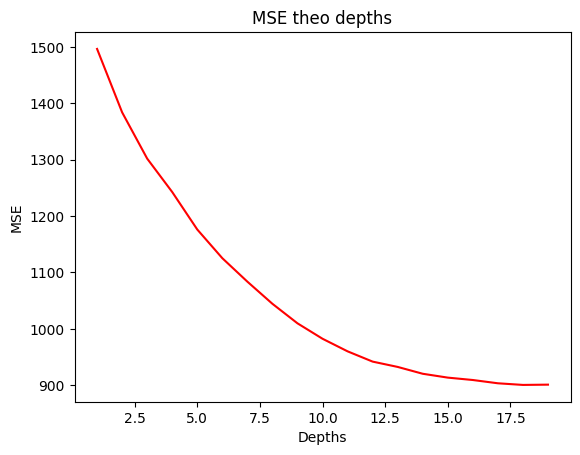

In [42]:
plt.plot(depths, mse, color = 'red')
plt.xlabel('Depths')
plt.ylabel('MSE')
plt.title('MSE theo depths')
plt.show()

In [49]:
mse

[1496.3364295783956,
 1383.9019772231163,
 1301.9000519063748,
 1242.6234891501476,
 1176.1712445193916,
 1125.3180899924846,
 1083.7324451643262,
 1044.4645336909846,
 1009.8700330540242,
 982.5007723279874,
 960.1991991599152,
 941.9876629547439,
 932.5591097537983,
 920.4417797142083,
 913.6086508214927,
 909.3686708394706,
 903.5591734490515,
 900.6602952782658,
 901.1465491000296]

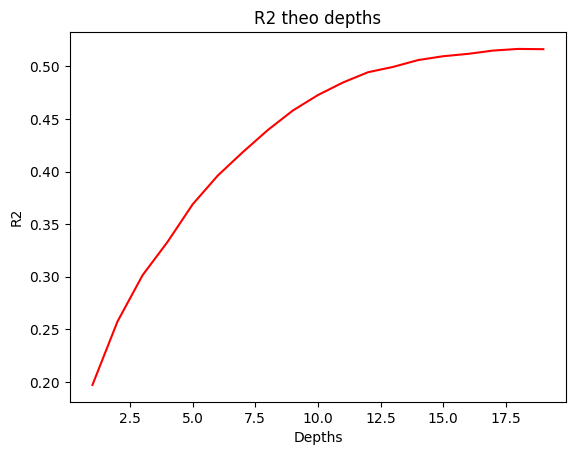

In [43]:
plt.plot(depths, r2, color = 'red')
plt.xlabel('Depths')
plt.ylabel('R2')
plt.title('R2 theo depths')
plt.show()

MSE ~900  
Depths 15 là tốt nhất

Model khá tệ sai số trung bình 30 AQI thật dao động(30-100) R2 thấp model chỉ diễn giải được một phần của dữ liệu 

In [44]:
from sklearn.tree import DecisionTreeRegressor

mse_dt = []
r2_dt = []
# Tạo model
for i in depths:
    print('depths thứ', i)
    dt = DecisionTreeRegressor(
    max_depth=i,
    random_state=42
    )

    # Train
    dt.fit(X_train, y_train)
    
    # Predict
    pred = dt.predict(X_test)
    
    # Metric
    mse_dt.append(mean_squared_error(y_test, pred))
    r2_dt.append(r2_score(y_test, pred))

depths thứ 1
depths thứ 2
depths thứ 3
depths thứ 4
depths thứ 5
depths thứ 6
depths thứ 7
depths thứ 8
depths thứ 9
depths thứ 10
depths thứ 11
depths thứ 12
depths thứ 13
depths thứ 14
depths thứ 15
depths thứ 16
depths thứ 17
depths thứ 18
depths thứ 19


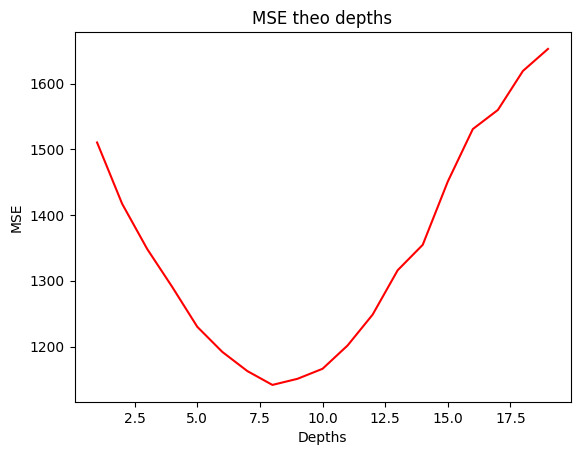

In [45]:
plt.plot(depths, mse_dt, color = 'red')
plt.xlabel('Depths')
plt.ylabel('MSE')
plt.title('MSE theo depths')
plt.show()

In [47]:
mse_dt

[1510.3282897547801,
 1417.1187909170894,
 1348.3677523861695,
 1290.6054162407515,
 1230.0161186919293,
 1191.811912342895,
 1162.64852538883,
 1141.6137416032207,
 1150.915880470497,
 1166.1430135299265,
 1201.5851566288513,
 1248.533806113426,
 1316.013609381914,
 1354.7062825586154,
 1450.856290664208,
 1530.7192494459641,
 1559.7690954862103,
 1619.0756227269842,
 1652.5881231893911]

Depths 8 là tốt nhất  
MSE~1150 rất cao sai số rất lớn  
Mô hình không diễn tả được AQI 

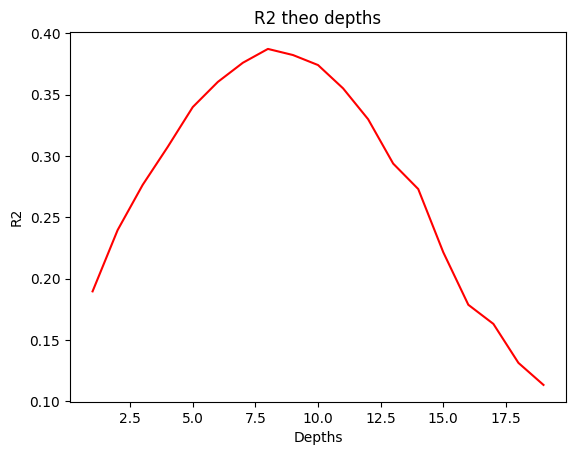

In [46]:
plt.plot(depths, r2_dt, color = 'red')
plt.xlabel('Depths')
plt.ylabel('R2')
plt.title('R2 theo depths')
plt.show()

In [48]:
r2_dt

[0.18955555448089856,
 0.2395719125899627,
 0.2764638238909821,
 0.3074591808652345,
 0.3399714896059518,
 0.3604719245385899,
 0.3761210421044694,
 0.3874083389109869,
 0.382416797119993,
 0.374245894480542,
 0.3552275868671154,
 0.3300348705169672,
 0.2938251059812401,
 0.27306255900979004,
 0.22146831917836496,
 0.17861373465760222,
 0.16302554331787367,
 0.13120157106538,
 0.11321871261039873]

Mô hình tốt nhất tại depths = 8  
R2~0.39 rất thấp không diễn tả hoàn toàn AQI dựa vào các thuộc tính đầu vào

In [52]:
trees = [100, 200, 300, 400, 500]
mse_rf = []
r2_rf = []
for i in trees:
    print('số cây', i)
    regressor = RandomForestRegressor(n_estimators=i, random_state=42, max_depth=15)
    regressor.fit(X_train, y_train)
    predictions = regressor.predict(X_test)
    mse_rf.append(mean_squared_error(y_test, predictions))
    r2_rf.append(r2_score(y_test, predictions))

số cây 100
số cây 200
số cây 300
số cây 400
số cây 500


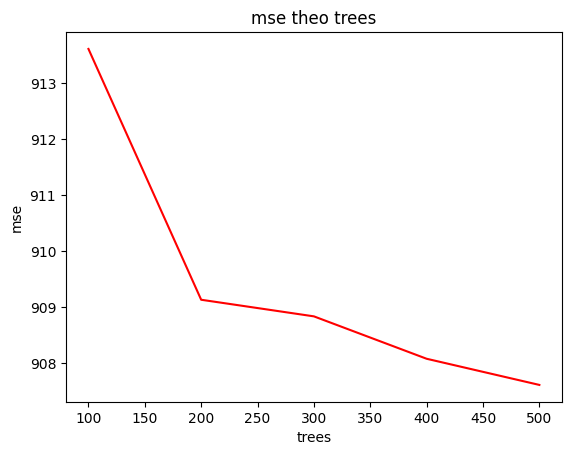

In [53]:
plt.plot(trees, mse_rf, color = 'red')
plt.xlabel('trees')
plt.ylabel('mse')
plt.title('mse theo trees')
plt.show()

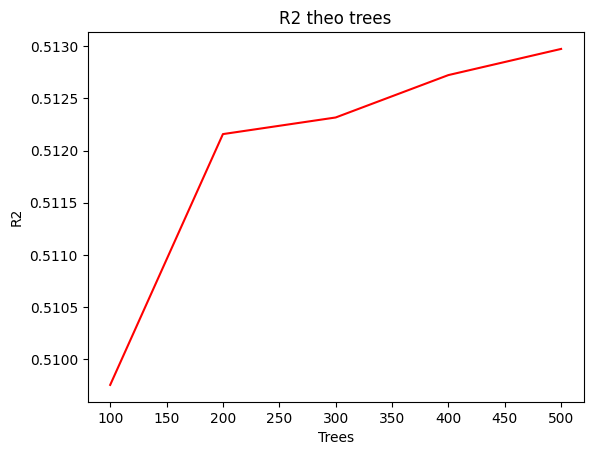

In [54]:
plt.plot(trees, r2_rf, color = 'red')
plt.xlabel('Trees')
plt.ylabel('R2')
plt.title('R2 theo trees')
plt.show()

200 cây là tối ưu

In [55]:
regressor = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=15)
regressor.fit(X_train, y_train)
predictions = regressor.predict(X_test)
print(mean_squared_error(y_test, predictions))
print(r2_score(y_test, predictions))

909.1338803448879
0.512157384221168


Mô hình random forest có hiệu quả hơn Decison tree một chút MSE 900 < 1150, R2 ~0.51 > 0.39  
Tuy nhiên MSE vẫn rất cao  
Từ phân tích và trực quan hóa dữ liệu ta cũng có thể rút ra được một vài điểm: Dữ liệu về không khí này có tính thời vụ, tăng giảm theo chu kì thời gian nhất định (mùa, thứ, ngày) và nó có tính nhớ, dữ liệu tiếp theo sẽ phụ thuộc vào dữ liệu trước đó, mô hình random forest không thể diễn tả tốt các đặc trưng trên.